# Black-Scholes Engine

Loads a saved options snapshot, runs the Black-Scholes pricer across every liquid strike, computes Greeks and implied volatility, and produces a full analysis dashboard.

**Workflow:**
1. Run cell 2 to see all available snapshots
2. Paste the slug into cell 3
3. Run all remaining cells top-to-bottom

## 1. Imports & Path Setup

In [10]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import copy

# ── PATH CONFIG ────────────────────────────────────────────────────────────────
PROJECT_ROOT = "." 
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# ───────────────────────────────────────────────────────────────────────────────

from params import SharedParameters
from BlackScholes import bs_price, bs_greeks, implied_volatility

# Plot style
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

CALL_COLOR = '#378ADD'
PUT_COLOR  = '#D85A30'
BS_COLOR   = '#1D9E75'
SPOT_COLOR = '#888888'

print("Imports OK.")
print(f"Looking for snapshots in: {os.path.abspath(DATA_DIR)}")

Imports OK.
Looking for snapshots in: /Users/alankrit/Desktop/OptionsPricing/data


## 2. List Available Snapshots

Run this cell to see everything in your `data/` folder, then copy a slug into cell 3.

In [11]:
def list_snapshots(data_dir=DATA_DIR):
    if not os.path.exists(data_dir):
        print(f"Data directory not found: {os.path.abspath(data_dir)}")
        print("Run OptionsData.ipynb first to fetch and save a snapshot.")
        return []

    meta_files = sorted(f for f in os.listdir(data_dir) if f.endswith("_meta.json"))

    if not meta_files:
        print("No snapshots found. Run OptionsData.ipynb first.")
        return []

    slugs = []
    print(f"{'#':<3}  {'Slug':<48}  {'Ticker':<6}  {'Expiry':<12}  "
          f"{'Spot':>7}  {'DTE':>5}  {'T':>6}  {'Calls':>6}  {'Puts':>5}")
    print("─" * 115)

    for i, mf in enumerate(meta_files):
        with open(os.path.join(data_dir, mf)) as f:
            m = json.load(f)
        slug = mf.replace("_meta.json", "")
        slugs.append(slug)
        print(
            f"{i:<3}  {slug:<48}  {m['ticker']:<6}  {m['expiry']:<12}  "
            f"${m['spot']:>6.2f}  {m.get('dte','?'):>5}  "
            f"{m['T']:>6.4f}  {m.get('n_calls','?'):>6}  {m.get('n_puts','?'):>5}"
        )
    return slugs

available_slugs = list_snapshots()

#    Slug                                              Ticker  Expiry           Spot    DTE       T   Calls   Puts
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
0    MSFT_2026-07-10_20260602_0214                     MSFT    2026-07-10    $460.52     37  0.1014      38     27


## 3. Select Snapshot

Paste the slug from cell 2, **or** set `SLUG_INDEX` to the row number to pick by index.

In [12]:
# ── CHOOSE ONE OF THESE TWO METHODS ───────────────────────────────────────────

# Method A — paste slug directly:
SLUG = ""   # e.g. "META_2026-06-05_20260525_1430" 

# Method B — pick by index from the table above (used if SLUG is empty):
SLUG_INDEX = 0

# ── OPTIONAL ──────────────────────────────────────────────────────────────────
Q = 0.0   # continuous dividend yield; 0 is fine for most stocks
# ───────────────────────────────────────────────────────────────────────────────

if not SLUG:
    if not available_slugs:
        raise RuntimeError("No snapshots available. Run OptionsData.ipynb first.")
    SLUG = available_slugs[SLUG_INDEX]
    print(f"Using index {SLUG_INDEX}: {SLUG}")

# Load
meta_path  = os.path.join(DATA_DIR, f"{SLUG}_meta.json")
calls_path = os.path.join(DATA_DIR, f"{SLUG}_calls.csv")
puts_path  = os.path.join(DATA_DIR, f"{SLUG}_puts.csv")

for p in [meta_path, calls_path, puts_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")

with open(meta_path) as f:
    meta = json.load(f)

calls_mkt = pd.read_csv(calls_path)
puts_mkt  = pd.read_csv(puts_path)

S      = float(meta['spot'])
r      = float(meta['r'])
T      = float(meta['T'])
TICKER = meta['ticker']
EXPIRY = meta['expiry']
DTE    = meta.get('dte', round(T * 365))

print(f"\nLoaded snapshot: {SLUG}")
print(f"  Ticker  : {TICKER}")
print(f"  Expiry  : {EXPIRY}  ({DTE} DTE)")
print(f"  Spot    : ${S:.2f}")
print(f"  r       : {r:.2%}")
print(f"  T       : {T:.4f} years")
print(f"  q       : {Q:.2%}")
print(f"  Calls   : {len(calls_mkt)} liquid strikes")
print(f"  Puts    : {len(puts_mkt)} liquid strikes")

Using index 0: MSFT_2026-07-10_20260602_0214

Loaded snapshot: MSFT_2026-07-10_20260602_0214
  Ticker  : MSFT
  Expiry  : 2026-07-10  (37 DTE)
  Spot    : $460.52
  r       : 3.60%
  T       : 0.1014 years
  q       : 0.00%
  Calls   : 38 liquid strikes
  Puts    : 27 liquid strikes


## 4. Run Black-Scholes Engine

For every liquid strike we compute:

- **BS price** using the yfinance IV as the volatility input (this shows how BS re-prices given market vol).
A large error at a given strike means the market is pricing something BS doesn't account for (e.g. skew, jumps, demand for hedging).

- **Our IV** backed out from the market mid via Newton-Raphson (independent of yfinance's IV)
- **Full Greeks** at our IV
- **Price error**: BS price − market mid

In [13]:
def run_bs_engine(df, option_type, S, r, T, q=0.0):
    """
    Price every strike in df using Black-Scholes.

    Two pricing passes:
      1. Using yfinance IV  → shows how BS re-prices given market-reported vol
      2. Using our IV (NR)  → independently backed out from market mid price

    Returns a DataFrame with prices, Greeks, and both IVs.
    """
    records = []

    for _, row in df.iterrows():
        K        = float(row['strike'])
        mid      = float(row['mid'])
        yf_iv    = float(row['impliedVolatility'])
        moneyness = float(row.get('moneyness', K / S))

        rec = {
            'strike'    : K,
            'moneyness' : round(moneyness, 4),
            'market_mid': round(mid, 4),
            'yf_iv'     : round(yf_iv, 4),
            'inTheMoney': row.get('inTheMoney', K < S if option_type == 'call' else K > S),
        }

        # ── Pass 1: BS price using yfinance IV ─────────────────────────────
        try:
            p_yf    = SharedParameters(S=S, K=K, r=r, sigma=yf_iv, T=T)
            bs_yf   = bs_price(p_yf, option_type, q=q)
            rec['bs_price_yf_iv'] = round(bs_yf, 4)
            rec['error_yf_iv']    = round(bs_yf - mid, 4)
        except Exception as e:
            rec['bs_price_yf_iv'] = np.nan
            rec['error_yf_iv']    = np.nan

        # ── Pass 2: Back out our IV, then price + Greeks ────────────────────
        try:
            p_seed  = SharedParameters(S=S, K=K, r=r, sigma=max(yf_iv, 0.05), T=T)
            our_iv  = implied_volatility(mid, p_seed, option_type, q=q)
            p_iv    = SharedParameters(S=S, K=K, r=r, sigma=our_iv, T=T)
            bs_our  = bs_price(p_iv, option_type, q=q)
            g       = bs_greeks(p_iv, option_type, q=q)

            rec.update({
                'our_iv'       : round(our_iv, 4),
                'iv_diff'      : round(our_iv - yf_iv, 4),   # our IV minus yfinance IV
                'bs_price_our_iv': round(bs_our, 4),
                'error_our_iv' : round(bs_our - mid, 6),     # should be ~0 by construction
                'delta'        : round(g.delta, 4),
                'gamma'        : round(g.gamma, 6),
                'theta'        : round(g.theta, 4),
                'vega'         : round(g.vega,  4),
                'rho'          : round(g.rho,   4),
            })
        except Exception as e:
            rec.update({
                'our_iv': np.nan, 'iv_diff': np.nan,
                'bs_price_our_iv': np.nan, 'error_our_iv': np.nan,
                'delta': np.nan, 'gamma': np.nan,
                'theta': np.nan, 'vega': np.nan, 'rho': np.nan,
                'iv_error': str(e),
            })

        records.append(rec)

    return pd.DataFrame(records)


calls_bs = run_bs_engine(calls_mkt, 'call', S, r, T, Q)
puts_bs  = run_bs_engine(puts_mkt,  'put',  S, r, T, Q)

n_call_ok = calls_bs['our_iv'].notna().sum()
n_put_ok  = puts_bs['our_iv'].notna().sum()

print(f"Black-Scholes engine complete.")
print(f"  Calls priced: {n_call_ok}/{len(calls_bs)}  (NR converged)")
print(f"  Puts  priced: {n_put_ok}/{len(puts_bs)}  (NR converged)")

if n_call_ok < len(calls_bs) or n_put_ok < len(puts_bs):
    print("\n  Rows where NR failed (check 'iv_error' column):")
    failed = pd.concat([
        calls_bs[calls_bs['our_iv'].isna()][['strike','market_mid']].assign(type='call'),
        puts_bs[ puts_bs['our_iv'].isna()][['strike','market_mid']].assign(type='put'),
    ])
    display(failed)

Black-Scholes engine complete.
  Calls priced: 29/38  (NR converged)
  Puts  priced: 11/27  (NR converged)

  Rows where NR failed (check 'iv_error' column):


,strike,market_mid,type
29,510.0000,6.0500,call
30,515.0000,5.6750,call
31,520.0000,4.9500,call
32,525.0000,4.4000,call
33,530.0000,3.9250,call
34,535.0000,3.5500,call
35,540.0000,2.9850,call
36,550.0000,2.4350,call
37,555.0000,2.1450,call
0,350.0000,0.5350,put


## 5. Results Tables

In [14]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

price_cols  = ['strike', 'moneyness', 'market_mid', 'bs_price_yf_iv', 'error_yf_iv', 'bs_price_our_iv', 'error_our_iv', 'our_iv', 'yf_iv', 'iv_diff']
greeks_cols = ['strike', 'moneyness', 'our_iv', 'delta', 'gamma', 'theta', 'vega', 'rho']

print("=" * 80)
print(f"CALLS — {TICKER} | {EXPIRY} | Spot ${S:.2f}")
print("=" * 80)
print("\n── Prices & IV ──")
display(calls_bs[price_cols])
print("\n── Greeks ──")
display(calls_bs[greeks_cols])

print("\n" + "=" * 80)
print(f"PUTS — {TICKER} | {EXPIRY} | Spot ${S:.2f}")
print("=" * 80)
print("\n── Prices & IV ──")
display(puts_bs[price_cols])
print("\n── Greeks ──")
display(puts_bs[greeks_cols])

CALLS — MSFT | 2026-07-10 | Spot $460.52

── Prices & IV ──


,strike,moneyness,market_mid,bs_price_yf_iv,error_yf_iv,bs_price_our_iv,error_our_iv,our_iv,yf_iv,iv_diff
0,350.0000,0.7600,112.8500,113.7706,0.9206,112.8500,0.0000,0.5016,0.5701,-0.0686
1,355.0000,0.7709,108.0250,108.9443,0.9193,108.0250,0.0000,0.4932,0.5559,-0.0628
2,370.0000,0.8034,93.4250,94.3548,0.9298,93.4250,0.0000,0.4518,0.5038,-0.0520
3,380.0000,0.8252,83.8750,86.2300,2.3550,83.8750,0.0000,0.4308,0.5319,-0.1012
4,385.0000,0.8360,79.1000,81.4772,2.3772,79.1000,0.0000,0.4183,0.5140,-0.0957
5,390.0000,0.8469,74.4250,76.7709,2.3459,74.4250,0.0000,0.4091,0.4970,-0.0879
6,395.0000,0.8577,69.7000,72.1108,2.4108,69.7000,0.0000,0.3963,0.4808,-0.0845
7,400.0000,0.8686,65.1500,67.4979,2.3479,65.1500,0.0000,0.3888,0.4651,-0.0763
8,405.0000,0.8794,60.6750,62.9788,2.3038,60.6750,0.0000,0.3816,0.4511,-0.0695
9,410.0000,0.8903,56.2750,58.5540,2.2790,56.2750,0.0000,0.3745,0.4383,-0.0638



── Greeks ──


,strike,moneyness,our_iv,delta,gamma,theta,vega,rho
0,350.0000,0.7600,0.5016,0.9657,0.0010,-0.1082,0.1114,0.3364
1,355.0000,0.7709,0.4932,0.9607,0.0012,-0.1159,0.1245,0.3390
2,370.0000,0.8034,0.4518,0.9472,0.0016,-0.1302,0.1578,0.3475
3,380.0000,0.8252,0.4308,0.9327,0.0021,-0.1452,0.1909,0.3504
4,385.0000,0.8360,0.4183,0.9249,0.0023,-0.1516,0.2077,0.3516
5,390.0000,0.8469,0.4091,0.9145,0.0026,-0.1609,0.2291,0.3515
6,395.0000,0.8577,0.3963,0.9046,0.0029,-0.1673,0.2486,0.3516
7,400.0000,0.8686,0.3888,0.8906,0.0033,-0.1783,0.2746,0.3497
8,405.0000,0.8794,0.3816,0.8746,0.0037,-0.1898,0.3026,0.3468
9,410.0000,0.8903,0.3745,0.8565,0.0041,-0.2013,0.3318,0.3428



PUTS — MSFT | 2026-07-10 | Spot $460.52

── Prices & IV ──


,strike,moneyness,market_mid,bs_price_yf_iv,error_yf_iv,bs_price_our_iv,error_our_iv,our_iv,yf_iv,iv_diff
0,350.0000,0.7600,0.5350,0.8056,0.2706,NaN,NaN,NaN,0.4774,NaN
1,355.0000,0.7709,0.4550,0.5847,0.1297,NaN,NaN,NaN,0.4321,NaN
2,360.0000,0.7817,0.6400,0.6931,0.0531,NaN,NaN,NaN,0.4247,NaN
3,365.0000,0.7926,0.7550,0.8033,0.0483,NaN,NaN,NaN,0.4157,NaN
4,370.0000,0.8034,0.8300,0.8359,0.0059,NaN,NaN,NaN,0.3984,NaN
5,375.0000,0.8143,1.0150,1.0419,0.0269,NaN,NaN,NaN,0.3949,NaN
6,380.0000,0.8252,1.1400,1.1187,-0.0213,NaN,NaN,NaN,0.3798,NaN
7,385.0000,0.8360,1.3500,1.3171,-0.0329,NaN,NaN,NaN,0.3718,NaN
8,390.0000,0.8469,1.5850,1.5337,-0.0513,NaN,NaN,NaN,0.3630,NaN
9,395.0000,0.8577,1.9200,1.8590,-0.0610,NaN,NaN,NaN,0.3578,NaN



── Greeks ──


,strike,moneyness,our_iv,delta,gamma,theta,vega,rho
0,350.0000,0.7600,NaN,NaN,NaN,NaN,NaN,NaN
1,355.0000,0.7709,NaN,NaN,NaN,NaN,NaN,NaN
2,360.0000,0.7817,NaN,NaN,NaN,NaN,NaN,NaN
3,365.0000,0.7926,NaN,NaN,NaN,NaN,NaN,NaN
4,370.0000,0.8034,NaN,NaN,NaN,NaN,NaN,NaN
5,375.0000,0.8143,NaN,NaN,NaN,NaN,NaN,NaN
6,380.0000,0.8252,NaN,NaN,NaN,NaN,NaN,NaN
7,385.0000,0.8360,NaN,NaN,NaN,NaN,NaN,NaN
8,390.0000,0.8469,NaN,NaN,NaN,NaN,NaN,NaN
9,395.0000,0.8577,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Summary Statistics

In [15]:
def summarise(df, label):
    ok = df.dropna(subset=['our_iv'])
    if ok.empty:
        print(f"{label}: no converged rows to summarise.")
        return

    atm_mask = (ok['moneyness'] >= 0.97) & (ok['moneyness'] <= 1.03)
    atm = ok[atm_mask]

    print(f"\n{'─'*60}")
    print(f"{label}")
    print(f"{'─'*60}")
    print(f"  Strikes analysed     : {len(ok)}")
    print(f"  IV range             : {ok['our_iv'].min():.1%} – {ok['our_iv'].max():.1%}")
    print(f"  IV (avg all)         : {ok['our_iv'].mean():.1%}")
    if not atm.empty:
        print(f"  IV (ATM ±3%)         : {atm['our_iv'].mean():.1%}")
        print(f"  Delta (ATM)          : {atm['delta'].mean():.3f}")
    print(f"  Max |price error|    : ${ok['error_yf_iv'].abs().max():.4f}   (BS vs market using yf IV)")
    print(f"  Avg |price error|    : ${ok['error_yf_iv'].abs().mean():.4f}")
    print(f"  IV vs yfinance diff  : {ok['iv_diff'].mean():+.4f} avg  (our IV − yf IV)")

summarise(calls_bs, f"CALLS  {TICKER} | {EXPIRY}")
summarise(puts_bs,  f"PUTS   {TICKER} | {EXPIRY}")

# Put-call parity spot check (matching strikes only)
merged = calls_bs[['strike','bs_price_our_iv']].merge(
    puts_bs[['strike','bs_price_our_iv']], on='strike', suffixes=('_c','_p')
)
if not merged.empty:
    merged['pcp_lhs'] = merged['bs_price_our_iv_c'] - merged['bs_price_our_iv_p']
    merged['pcp_rhs'] = S * np.exp(-Q * T) - merged['strike'] * np.exp(-r * T)
    merged['pcp_err'] = (merged['pcp_lhs'] - merged['pcp_rhs']).abs()
    print(f"\n{'─'*60}")
    print(f"Put-Call Parity check  (max error should be < 1e-6)")
    print(f"{'─'*60}")
    print(f"  Matching strikes : {len(merged)}")
    print(f"  Max PCP error    : {merged['pcp_err'].max():.2e}")
    print(f"  Mean PCP error   : {merged['pcp_err'].mean():.2e}")


────────────────────────────────────────────────────────────
CALLS  MSFT | 2026-07-10
────────────────────────────────────────────────────────────
  Strikes analysed     : 29
  IV range             : 34.2% – 50.2%
  IV (avg all)         : 37.7%
  IV (ATM ±3%)         : 34.5%
  Delta (ATM)          : 0.540
  Max |price error|    : $2.4108   (BS vs market using yf IV)
  Avg |price error|    : $1.5059
  IV vs yfinance diff  : -0.0434 avg  (our IV − yf IV)

────────────────────────────────────────────────────────────
PUTS   MSFT | 2026-07-10
────────────────────────────────────────────────────────────
  Strikes analysed     : 11
  IV range             : 32.5% – 34.6%
  IV (avg all)         : 33.1%
  IV (ATM ±3%)         : 33.0%
  Delta (ATM)          : -0.451
  Max |price error|    : $0.4756   (BS vs market using yf IV)
  Avg |price error|    : $0.3188
  IV vs yfinance diff  : +0.0060 avg  (our IV − yf IV)

────────────────────────────────────────────────────────────
Put-Call Parity check

## 7. Analysis Dashboard

Six plots:
1. **Price vs Strike** — market mid vs BS price (calls and puts)
2. **Price Error** — BS minus market mid; shows where BS misprices
3. **Implied Volatility Smile** — our IV vs yfinance IV
4. **Delta vs Strike** — how hedge ratio changes across strikes
5. **Gamma vs Strike** — convexity; peaks at ATM
6. **Theta vs Strike** — daily time decay

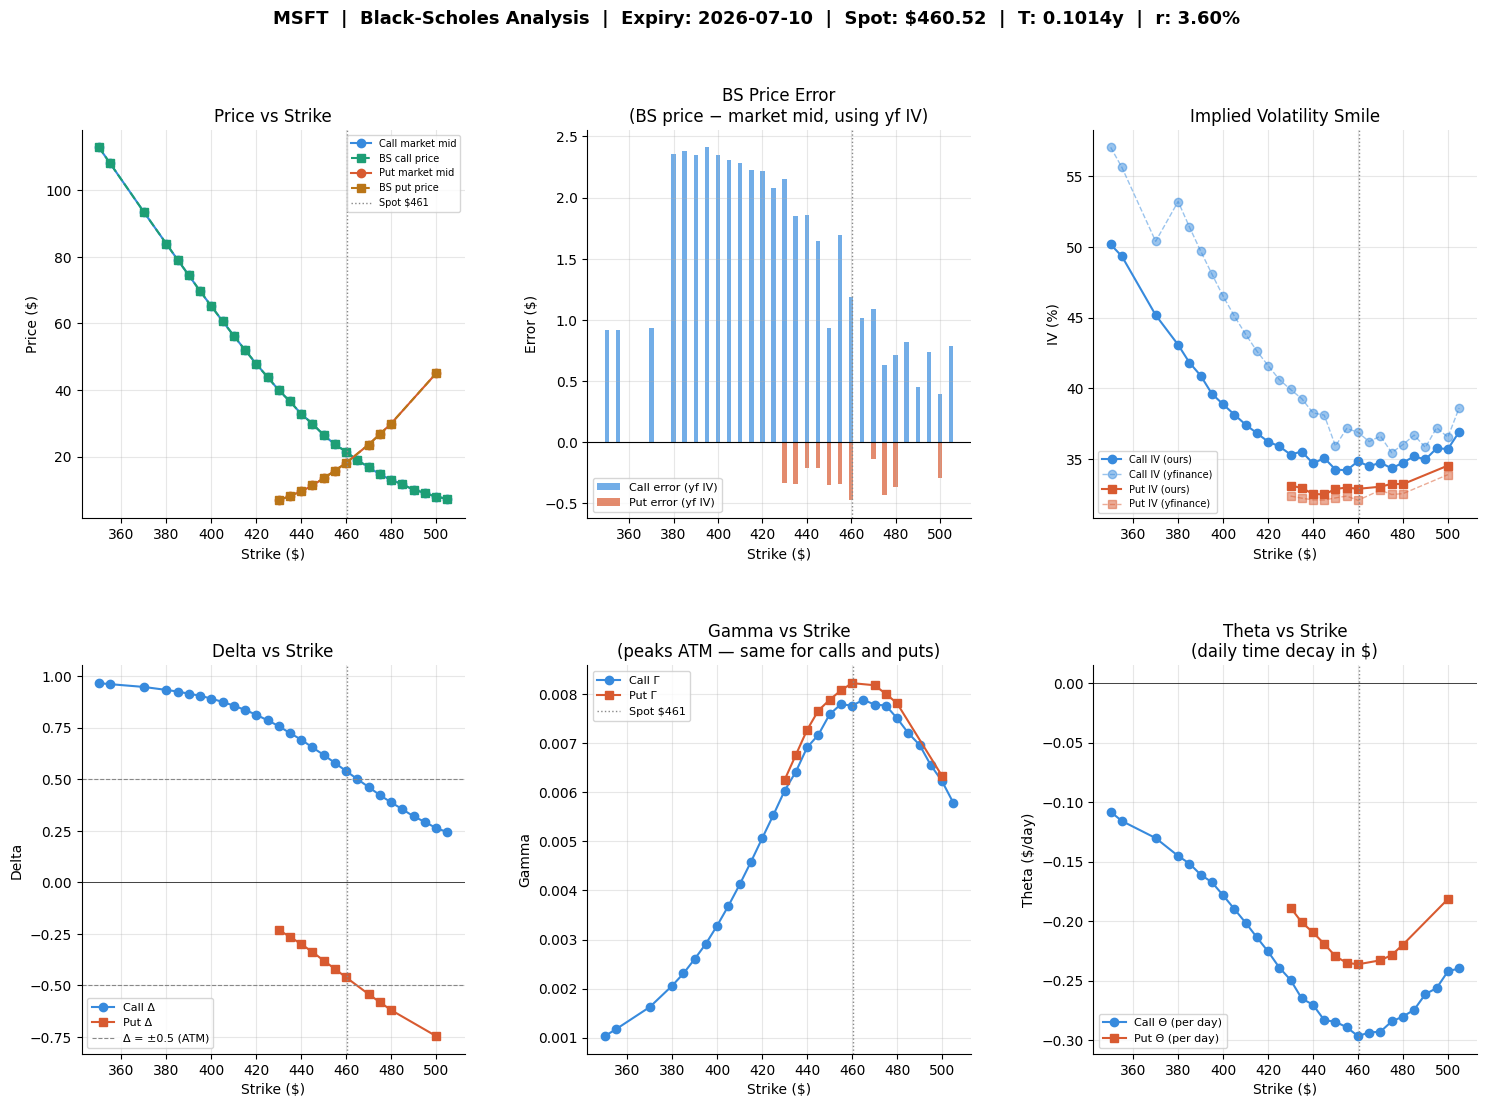

Dashboard saved to data/MSFT_2026-07-10_20260602_0214_bs_dashboard.png


In [16]:
c = calls_bs.dropna(subset=['our_iv'])
p = puts_bs.dropna(subset=['our_iv'])

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f"{TICKER}  |  Black-Scholes Analysis  |  Expiry: {EXPIRY}  "
    f"|  Spot: ${S:.2f}  |  T: {T:.4f}y  |  r: {r:.2%}",
    fontsize=13, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# ── 1. Price vs Strike ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
if not c.empty:
    ax1.plot(c['strike'], c['market_mid'],     'o-',  color=CALL_COLOR, label='Call market mid', lw=1.5)
    ax1.plot(c['strike'], c['bs_price_our_iv'],'s--', color=BS_COLOR,   label='BS call price',   lw=1.5)
if not p.empty:
    ax1.plot(p['strike'], p['market_mid'],     'o-',  color=PUT_COLOR,  label='Put market mid',  lw=1.5)
    ax1.plot(p['strike'], p['bs_price_our_iv'],'s--', color='#BA7517',  label='BS put price',    lw=1.5)
ax1.axvline(S, color=SPOT_COLOR, lw=1, linestyle=':', label=f'Spot ${S:.0f}')
ax1.set_title('Price vs Strike'); ax1.set_xlabel('Strike ($)'); ax1.set_ylabel('Price ($)')
ax1.legend(fontsize=7)

# ── 2. Price Error (BS − market) ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
if not c.empty:
    ax2.bar(c['strike'], c['error_yf_iv'], width=2, alpha=0.7,
            color=CALL_COLOR, label='Call error (yf IV)')
if not p.empty:
    ax2.bar(p['strike'], p['error_yf_iv'], width=2, alpha=0.7,
            color=PUT_COLOR,  label='Put error (yf IV)')
ax2.axhline(0, color='black', lw=0.8)
ax2.axvline(S, color=SPOT_COLOR, lw=1, linestyle=':')
ax2.set_title('BS Price Error\n(BS price − market mid, using yf IV)')
ax2.set_xlabel('Strike ($)'); ax2.set_ylabel('Error ($)')
ax2.legend(fontsize=8)

# ── 3. Implied Volatility Smile ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if not c.empty:
    ax3.plot(c['strike'], c['our_iv'] * 100, 'o-',  color=CALL_COLOR,  label='Call IV (ours)',     lw=1.5)
    ax3.plot(c['strike'], c['yf_iv']  * 100, 'o--', color=CALL_COLOR,  label='Call IV (yfinance)', lw=1,  alpha=0.5)
if not p.empty:
    ax3.plot(p['strike'], p['our_iv'] * 100, 's-',  color=PUT_COLOR,   label='Put IV (ours)',      lw=1.5)
    ax3.plot(p['strike'], p['yf_iv']  * 100, 's--', color=PUT_COLOR,   label='Put IV (yfinance)',  lw=1,  alpha=0.5)
ax3.axvline(S, color=SPOT_COLOR, lw=1, linestyle=':')
ax3.set_title('Implied Volatility Smile'); ax3.set_xlabel('Strike ($)'); ax3.set_ylabel('IV (%)')
ax3.legend(fontsize=7)

# ── 4. Delta vs Strike ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
if not c.empty:
    ax4.plot(c['strike'], c['delta'], 'o-', color=CALL_COLOR, label='Call Δ', lw=1.5)
if not p.empty:
    ax4.plot(p['strike'], p['delta'], 's-', color=PUT_COLOR,  label='Put Δ',  lw=1.5)
ax4.axhline( 0.5, color=SPOT_COLOR, lw=0.8, linestyle='--', label='Δ = ±0.5 (ATM)')
ax4.axhline(-0.5, color=SPOT_COLOR, lw=0.8, linestyle='--')
ax4.axhline(0,    color='black',    lw=0.5)
ax4.axvline(S,    color=SPOT_COLOR, lw=1,   linestyle=':')
ax4.set_title('Delta vs Strike'); ax4.set_xlabel('Strike ($)'); ax4.set_ylabel('Delta')
ax4.legend(fontsize=8)

# ── 5. Gamma vs Strike ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
if not c.empty:
    ax5.plot(c['strike'], c['gamma'], 'o-', color=CALL_COLOR, label='Call Γ', lw=1.5)
if not p.empty:
    ax5.plot(p['strike'], p['gamma'], 's-', color=PUT_COLOR,  label='Put Γ',  lw=1.5)
ax5.axvline(S, color=SPOT_COLOR, lw=1, linestyle=':', label=f'Spot ${S:.0f}')
ax5.set_title('Gamma vs Strike\n(peaks ATM — same for calls and puts)')
ax5.set_xlabel('Strike ($)'); ax5.set_ylabel('Gamma')
ax5.legend(fontsize=8)

# ── 6. Theta vs Strike ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
if not c.empty:
    ax6.plot(c['strike'], c['theta'], 'o-', color=CALL_COLOR, label='Call Θ (per day)', lw=1.5)
if not p.empty:
    ax6.plot(p['strike'], p['theta'], 's-', color=PUT_COLOR,  label='Put Θ (per day)',  lw=1.5)
ax6.axhline(0, color='black', lw=0.5)
ax6.axvline(S, color=SPOT_COLOR, lw=1, linestyle=':')
ax6.set_title('Theta vs Strike\n(daily time decay in $)')
ax6.set_xlabel('Strike ($)'); ax6.set_ylabel('Theta ($/day)')
ax6.legend(fontsize=8)

plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_bs_dashboard.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Dashboard saved to data/{SLUG}_bs_dashboard.png")

## 8. Stock Price Distribution

Under GBM, the terminal stock price $S_T$ is log-normally distributed. This plot shows what distribution of prices Black-Scholes is implicitly assuming, using the ATM implied volatility as σ.

1. `E[S_T]`   = expected stock price at expiry (risk-neutral)
2. `Median S_T` = most likely terminal price
3. `Std[S_T]`  = uncertainty range
4. 5th pct   = price with only 5% chance stock finishes below
5. 95th pct  = price with only 5% chance stock finishes above
6. P(S_T > S₀) = probability of a gain by expiry

ATM implied volatility used for distribution: 34.53%


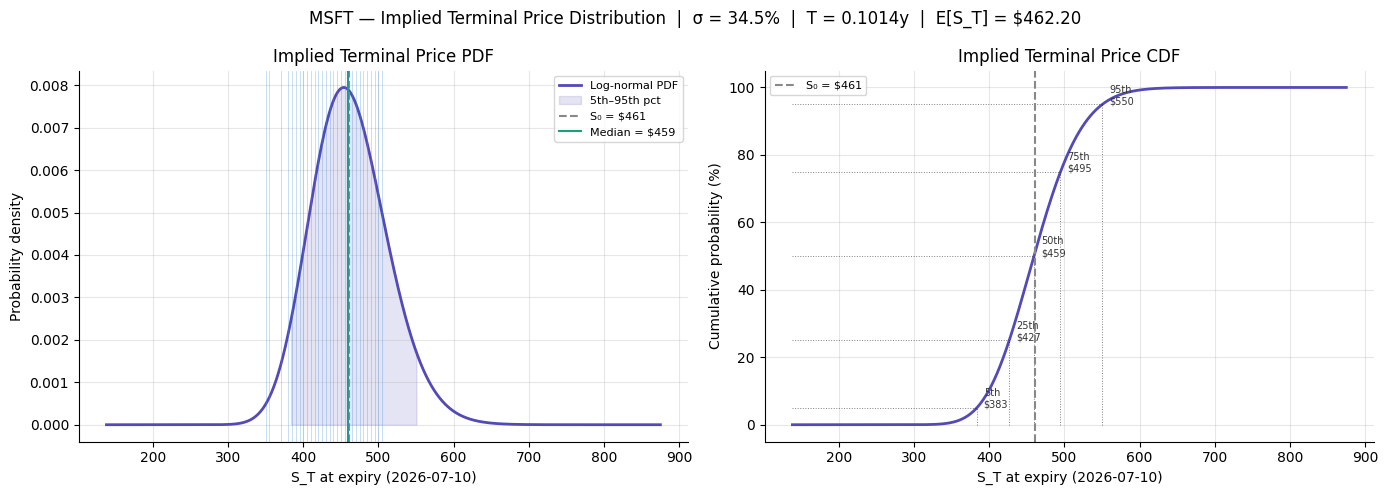


Distribution summary (σ = 34.53%, T = 0.1014y):
  E[S_T]        = $462.20
  Median S_T    = $459.42
  Std[S_T]      = $50.97
  5th  pct      = $383.42  (prob stock < this: 5%)
  95th pct      = $550.48  (prob stock > this: 5%)
  P(S_T > S₀)   = 49.1%


In [17]:
# Use ATM IV as the vol estimate for the distribution
atm_calls = calls_bs[
    (calls_bs['moneyness'] >= 0.97) & (calls_bs['moneyness'] <= 1.03)
].dropna(subset=['our_iv'])

sigma_atm = atm_calls['our_iv'].mean() if not atm_calls.empty else calls_bs['our_iv'].mean()

if np.isnan(sigma_atm):
    sigma_atm = 0.25   # fallback if no converged IV
    print(f"No ATM IV found — using fallback σ = {sigma_atm:.0%}")
else:
    print(f"ATM implied volatility used for distribution: {sigma_atm:.2%}")

# Log-normal parameters
mu_lognorm  = np.log(S) + (r - Q - 0.5 * sigma_atm**2) * T
sig_lognorm = sigma_atm * np.sqrt(T)

S_grid = np.linspace(S * 0.3, S * 1.9, 1000)
pdf    = (1 / (S_grid * sig_lognorm * np.sqrt(2 * np.pi))) * \
         np.exp(-0.5 * ((np.log(S_grid) - mu_lognorm) / sig_lognorm)**2)

# Key percentiles
from scipy.stats import lognorm
dist = lognorm(s=sig_lognorm, scale=np.exp(mu_lognorm))
p05, p25, p50, p75, p95 = dist.ppf([0.05, 0.25, 0.50, 0.75, 0.95])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"{TICKER} — Implied Terminal Price Distribution  |  "
    f"σ = {sigma_atm:.1%}  |  T = {T:.4f}y  |  E[S_T] = ${dist.mean():.2f}",
    fontsize=12
)

# Left: PDF
ax = axes[0]
ax.plot(S_grid, pdf, color='#534AB7', lw=2, label='Log-normal PDF')
ax.fill_between(S_grid, pdf,
    where=(S_grid >= p05) & (S_grid <= p95),
    alpha=0.15, color='#534AB7', label='5th–95th pct')
ax.axvline(S,   color=SPOT_COLOR,   lw=1.5, linestyle='--', label=f'S₀ = ${S:.0f}')
ax.axvline(p50, color='#1D9E75',    lw=1.5, linestyle='-',  label=f'Median = ${p50:.0f}')

# Mark all liquid call strikes on the distribution
if not calls_bs.empty:
    for _, row in calls_bs.dropna(subset=['our_iv']).iterrows():
        ax.axvline(row['strike'], color=CALL_COLOR, lw=0.5, alpha=0.4)

ax.set_xlabel(f'S_T at expiry ({EXPIRY})')
ax.set_ylabel('Probability density')
ax.set_title('Implied Terminal Price PDF')
ax.legend(fontsize=8)

# Right: CDF with percentile bands
ax = axes[1]
cdf = dist.cdf(S_grid)
ax.plot(S_grid, cdf * 100, color='#534AB7', lw=2)
for pct, val, lbl in [
    (5,  p05, '5th'),
    (25, p25, '25th'),
    (50, p50, '50th'),
    (75, p75, '75th'),
    (95, p95, '95th'),
]:
    ax.plot([S_grid[0], val], [pct, pct], 'k:', lw=0.7, alpha=0.5)
    ax.plot([val, val], [0, pct],          'k:', lw=0.7, alpha=0.5)
    ax.annotate(f'{lbl}\n${val:.0f}', xy=(val, pct),
                xytext=(5, 0), textcoords='offset points',
                fontsize=7, color='#333')
ax.axvline(S,   color=SPOT_COLOR, lw=1.5, linestyle='--', label=f'S₀ = ${S:.0f}')
ax.set_xlabel(f'S_T at expiry ({EXPIRY})')
ax.set_ylabel('Cumulative probability (%)')
ax.set_title('Implied Terminal Price CDF')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_bs_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDistribution summary (σ = {sigma_atm:.2%}, T = {T:.4f}y):")
print(f"  E[S_T]        = ${dist.mean():.2f}")
print(f"  Median S_T    = ${p50:.2f}")
print(f"  Std[S_T]      = ${dist.std():.2f}")
print(f"  5th  pct      = ${p05:.2f}  (prob stock < this: 5%)")
print(f"  95th pct      = ${p95:.2f}  (prob stock > this: 5%)")
print(f"  P(S_T > S₀)   = {(1 - dist.cdf(S))*100:.1f}%")

## 9. Save Results to CSV

In [18]:
calls_out = os.path.join(DATA_DIR, f"{SLUG}_bs_calls.csv")
puts_out  = os.path.join(DATA_DIR, f"{SLUG}_bs_puts.csv")

calls_bs.to_csv(calls_out, index=False)
puts_bs.to_csv(puts_out,   index=False)

print(f"Results saved:")
print(f"  {calls_out}")
print(f"  {puts_out}")
print()
print("These files are ready to load in MonteCarlo.ipynb for side-by-side comparison.")
print(f"\n  bs_calls = pd.read_csv('data/{SLUG}_bs_calls.csv')")
print(f"  bs_puts  = pd.read_csv('data/{SLUG}_bs_puts.csv')")

Results saved:
  ./data/MSFT_2026-07-10_20260602_0214_bs_calls.csv
  ./data/MSFT_2026-07-10_20260602_0214_bs_puts.csv

These files are ready to load in MonteCarlo.ipynb for side-by-side comparison.

  bs_calls = pd.read_csv('data/MSFT_2026-07-10_20260602_0214_bs_calls.csv')
  bs_puts  = pd.read_csv('data/MSFT_2026-07-10_20260602_0214_bs_puts.csv')
